In [1]:
import os

os.chdir('..')
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"  # set for determinism

## Loading the Dataset:

In this section the pointcloud is loaded. The SIREN paper suggests normalizing the point coordinates as periodic activations implicitly expect a bounded input. 

In [2]:
import open3d as o3d
import numpy as np
import torch
import matplotlib.pyplot as plt
import src.model.SIREN as si
from src.model.training import train
from src.model.training import chamfer_hausdorff
import src.loss.SDF_loss as loss
from src.mesh_extraction.marching_cubes_test import write_obj
import src.model.MLP as simple
import src.data.dataset as data
import src.model.pruning_module as pm
import src.mesh_extraction.marching_cubes_gpu as marching_cubes
import random


def set_seeds():
    random.seed(42)
    np.random.seed(42)
    torch.manual_seed(42)
    torch.cuda.manual_seed_all(42)
    torch.use_deterministic_algorithms(True)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

mesh = data.MeshDataset('data/pointclouds/lucy/Stanford_lucy.ply')

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Defining the Model

In this cell we will define the SIREN model. This particular INR uses sine activations for nonlinearity and is supposed to capture more information given the underlying data when compared to a model that uses ReLU activations. This way, a good INR accuracy can be achieved with fewer neurons.

In [3]:
size_per_layer = 256
set_seeds()
model = si.SIRENSDF(hidden_dims=[256, 256, 256])
model_loss = loss.Loss(lambda_surface=175,  lambda_eikonal=1, lambda_normal=15, lambda_inter=4, lambda_off=15, lambda_twd=1e-3, model=model)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4*2)

## Model training without pruning or densification



Step 0 | IoU 0.0316 | Loss 20.5324
Step 10 | Loss 5.2612
Step 20 | Loss 4.2544
Step 30 | Loss 3.6154
Step 40 | Loss 3.1776
Step 50 | Loss 2.7112
Step 60 | Loss 2.4012
Step 70 | Loss 2.1979
Step 80 | Loss 1.9564
Step 90 | Loss 1.7296
Step 100 | IoU 0.4591 | Loss 1.6401
Step 110 | Loss 1.5501
Step 120 | Loss 1.4561
Step 130 | Loss 1.3826
Step 140 | Loss 1.2750
Step 150 | Loss 1.2558
Step 160 | Loss 1.2025
Step 170 | Loss 1.0880
Step 180 | Loss 1.0490
Step 190 | Loss 0.9680
Step 200 | IoU 0.8064 | Loss 0.9481
Step 210 | Loss 0.8962
Step 220 | Loss 0.8772
Step 230 | Loss 0.8570
Step 240 | Loss 0.8375
Step 250 | Loss 0.7941
Step 260 | Loss 0.7686
Step 270 | Loss 0.7357
Step 280 | Loss 0.7382
Step 290 | Loss 0.7177
Step 300 | IoU 0.9032 | Loss 0.7045
Step 310 | Loss 0.6818
Step 320 | Loss 0.6826
Step 330 | Loss 0.6567
Step 340 | Loss 0.6519
Step 350 | Loss 0.6446
Step 360 | Loss 0.6199
Step 370 | Loss 0.6140
Step 380 | Loss 0.5993
Step 390 | Loss 0.5595
Step 400 | IoU 0.9348 | Loss 0.5994
St

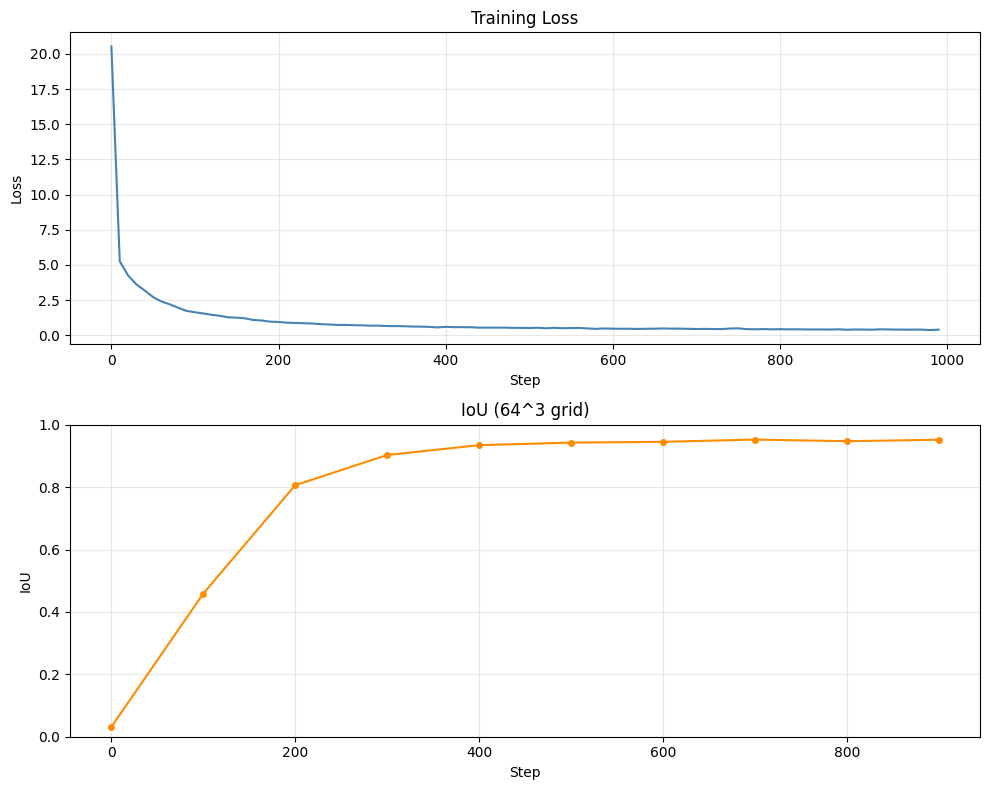

Saved training_curves.png


In [4]:
loss_hist, iou_hist, iou_steps = train(epochs=1000, data=mesh, no_surface=10000, no_off_surface=15000, model=model, loss=model_loss, optimizer=optimizer, scene=mesh.scene)
np.savez(
    "lucy_weights/history/large_unpruned_history.npz",
    loss=np.array(loss_hist),
    iou=np.array(iou_hist),
    steps=np.array(iou_steps)
)
torch.save(model.state_dict(), "lucy_weights/large_unpruned.pth")

#### Model size

In [5]:
model.neuron_counts()

Neuron counts per layer:
----------------------------------------
Hidden layer  0:  256 neurons
Hidden layer  1:  256 neurons
Hidden layer  2:  256 neurons
Final layer    :    1 neurons


In [36]:
model = si.SIRENSDF(hidden_dims=[256, 256, 256])
missing, unexpected = model.load_state_dict(torch.load("lucy_weights/large_unpruned.pth", map_location=torch.device("cuda")))
model.eval()
model.to(torch.device("cuda"))
print(missing)
print(unexpected)
marching_cubes.write_obj("lucy_256_unpruned_large.obj", model=model, resolution=256, level=0.0)

/tmp/ipykernel_52318/3304072733.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  missing, unexpected = model.load_state_dict(torch.load("lucy_weights/large_unpruned.pth",

[]
[]


In [7]:
chamfer, hausdorff = chamfer_hausdorff("lucy_128_unpruned_large.obj", "lucy_128_gt.obj")
print(f"chamfer: {chamfer:.4f} | hausdorff: {hausdorff:.4f}")

mesh1 triangles: 45198, vertices: 30547
mesh2 triangles: 44780, vertices: 30177
chamfer: 0.0040 | hausdorff: 0.0285


## Model training with densification

In [8]:
set_seeds()
model = si.SIRENSDF(hidden_dims=[151, 256, 256])
model_loss = loss.Loss(lambda_surface=175,  lambda_eikonal=1, lambda_normal=15, lambda_inter=4, lambda_off=15, lambda_twd=1e-3, model=model)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4*2)

tensor([2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
        2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
        2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       device='cuda:0')
Added 46 frequencies to the embedding layer.
Step 0 | IoU 0.0355 | Loss 19.0581
Step 10 | Loss 4.85

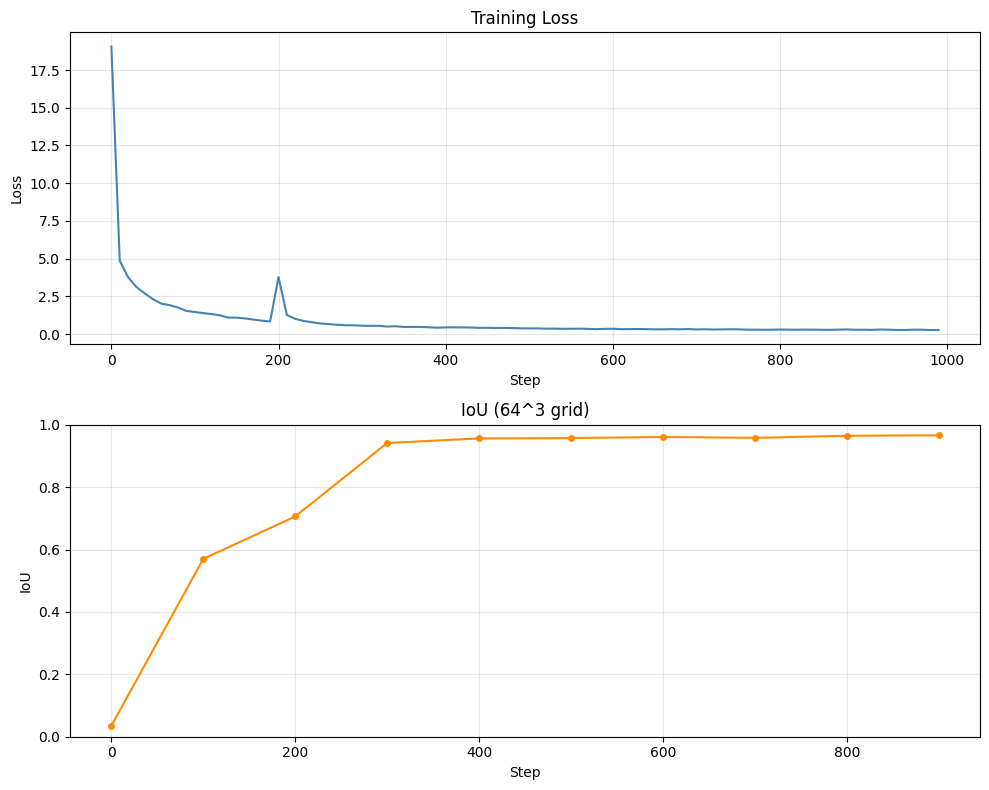

Saved training_curves.png


In [9]:
loss_hist, iou_hist, iou_steps = train(epochs=1000, data=mesh, no_surface=10000, no_off_surface=15000, model=model, loss=model_loss, optimizer=optimizer, scene=mesh.scene, densification=True)
np.savez(
    "lucy_weights/history/densified_history.npz",
    loss=np.array(loss_hist),
    iou=np.array(iou_hist),
    steps=np.array(iou_steps)
)
torch.save(model.state_dict(), "lucy_weights/densified.pth")

In [10]:
model.neuron_counts()

Neuron counts per layer:
----------------------------------------
Hidden layer  0:  256 neurons
Hidden layer  1:  256 neurons
Hidden layer  2:  256 neurons
Final layer    :    1 neurons


In [33]:
model = si.SIRENSDF(hidden_dims=[256, 256, 256])
missing, unexpected = model.load_state_dict(torch.load("lucy_weights/densified.pth", map_location=torch.device("cuda")))
model.eval()
model.to(torch.device("cuda"))
print(missing)
print(unexpected)
marching_cubes.write_obj("lucy_256_densified.obj", model=model, resolution=256, level=0.0)

/tmp/ipykernel_52318/2648070354.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  missing, unexpected = model.load_state_dict(torch.load("lucy_weights/densified.pth", map_

[]
[]


In [12]:
chamfer, hausdorff = chamfer_hausdorff("lucy_128_densified.obj", "lucy_128_gt.obj")
print(f"chamfer: {chamfer:.4f} | hausdorff: {hausdorff:.4f}")

mesh1 triangles: 45154, vertices: 30398
mesh2 triangles: 44780, vertices: 30177
chamfer: 0.0036 | hausdorff: 0.0185


## AIRe: Model training (no densification)

In [13]:
set_seeds()
size_per_layer = 256
model = si.SIRENSDF(hidden_dims=[256, 256, 256])
prune_AIRe = pm.AIRe(model, 0.6)
model_loss = loss.Loss(lambda_surface=175,  lambda_eikonal=1, lambda_normal=15, lambda_inter=4, lambda_off=15, lambda_twd=1e-3, model=model, pruning_module=prune_AIRe)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4*2)

Step 0 | IoU 0.0316 | Loss 20.5324
Step 10 | Loss 5.2612
Step 20 | Loss 4.2544
Step 30 | Loss 3.6154
Step 40 | Loss 3.1776
Step 50 | Loss 2.7112
Step 60 | Loss 2.4012
Step 70 | Loss 2.1979
Step 80 | Loss 1.9564
Step 90 | Loss 1.7296
Step 100 | IoU 0.4591 | Loss 1.6401
Step 110 | Loss 1.5501
Step 120 | Loss 1.4561
Step 130 | Loss 1.3826
Step 140 | Loss 1.2750
Step 150 | Loss 1.2558
Step 160 | Loss 1.2025
Step 170 | Loss 1.0880
Step 180 | Loss 1.0490
Step 190 | Loss 0.9680
TWD is now applied
Step 200 | IoU 0.8064 | Loss 0.9481
Step 210 | Loss 1.1209
Step 220 | Loss 1.1017
Step 230 | Loss 1.0829
Step 240 | Loss 1.0649
Step 250 | Loss 1.0182
Step 260 | Loss 0.9903
Step 270 | Loss 0.9604
Step 280 | Loss 0.9664
Step 290 | Loss 0.9489
Step 300 | IoU 0.9095 | Loss 0.9334
Step 310 | Loss 0.9038
Step 320 | Loss 0.9167
Step 330 | Loss 0.8838
Step 340 | Loss 0.8858
Step 350 | Loss 0.8499
Step 360 | Loss 0.8295
Step 370 | Loss 0.8174
Step 380 | Loss 0.8095
Step 390 | Loss 0.7740
Step 400 | IoU 0.92

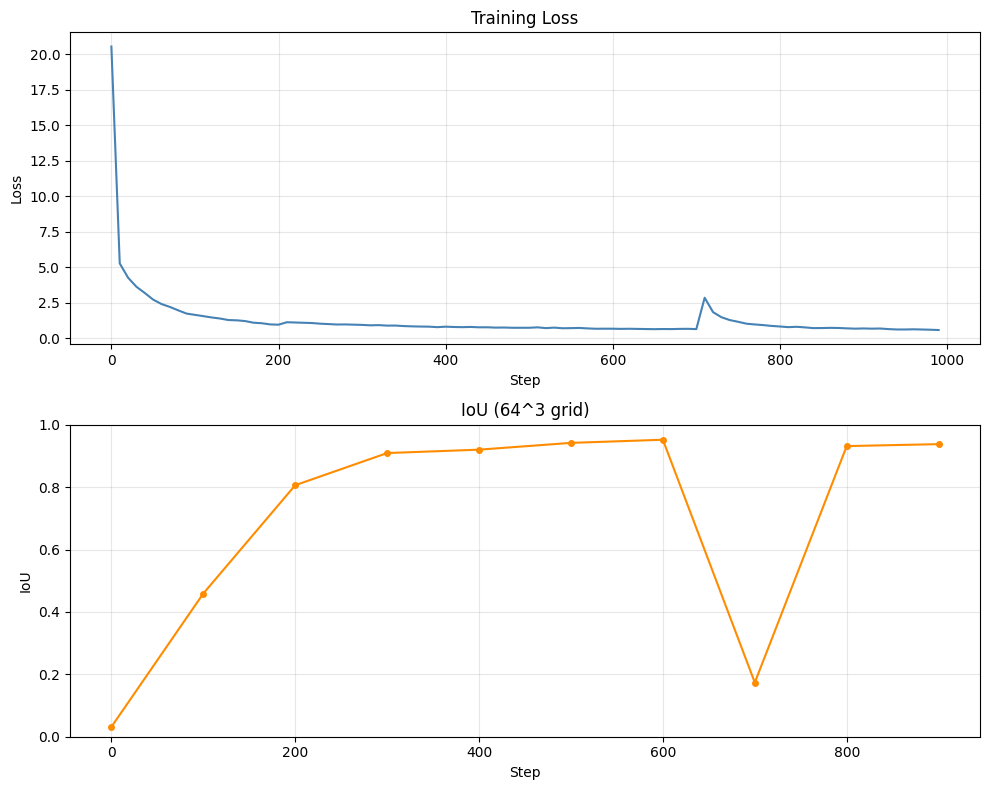

Saved training_curves.png


In [14]:
loss_hist, iou_hist, iou_steps = train(epochs=1000, data=mesh, no_surface=10000, no_off_surface=15000, model=model, loss=model_loss, optimizer=optimizer, scene=mesh.scene, pruning_module=prune_AIRe)
np.savez(
    "lucy_weights/history/AIRe_history.npz",
    loss=np.array(loss_hist),
    iou=np.array(iou_hist),
    steps=np.array(iou_steps)
)
torch.save(model.state_dict(), "lucy_weights/AIRe.pth")

In [15]:
model.neuron_counts()

Neuron counts per layer:
----------------------------------------
Hidden layer  0:  256 neurons
Hidden layer  1:  103 neurons
Hidden layer  2:  103 neurons
Final layer    :    1 neurons


In [16]:
model = si.SIRENSDF(hidden_dims=[256, 103, 103])
missing, unexpected = model.load_state_dict(torch.load("lucy_weights/AIRe.pth", map_location=torch.device("cuda")))
model.eval()
model.to(torch.device("cuda"))
print(missing)
print(unexpected)
marching_cubes.write_obj("lucy_128_AIRe.obj", model=model, resolution=128, level=0.0)

[]
[]


/tmp/ipykernel_52318/907772350.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  missing, unexpected = model.load_state_dict(torch.load("lucy_weights/AIRe.pth", map_locati

In [17]:
chamfer, hausdorff = chamfer_hausdorff("lucy_128_AIRe.obj", "lucy_128_gt.obj")
print(f"chamfer: {chamfer:.4f} | hausdorff: {hausdorff:.4f}")

mesh1 triangles: 44758, vertices: 30115
mesh2 triangles: 44780, vertices: 30177
chamfer: 0.0041 | hausdorff: 0.0701


## DepGraph: Model training (no densification)

In [18]:
set_seeds()
device = torch.device("cuda")
model = si.SIRENSDF(hidden_dims=[256, 256, 256]).to(device)
prune_DepGraph = pm.DepGraph(model, 0.6)
model_loss = loss.Loss(lambda_surface=175,  lambda_eikonal=1, lambda_normal=15, lambda_inter=4, lambda_off=15, lambda_twd=1e-3, model=model, pruning_module=prune_DepGraph)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4*2)

Step 0 | IoU 0.0316 | Loss 20.5324
Step 10 | Loss 5.2612
Step 20 | Loss 4.2544
Step 30 | Loss 3.6154
Step 40 | Loss 3.1776
Step 50 | Loss 2.7112
Step 60 | Loss 2.4012
Step 70 | Loss 2.1979
Step 80 | Loss 1.9564
Step 90 | Loss 1.7296
Step 100 | IoU 0.4591 | Loss 1.6401
Step 110 | Loss 1.5501
Step 120 | Loss 1.4561
Step 130 | Loss 1.3826
Step 140 | Loss 1.2750
Step 150 | Loss 1.2558
Step 160 | Loss 1.2025
Step 170 | Loss 1.0880
Step 180 | Loss 1.0490
Step 190 | Loss 0.9680
TWD is now applied
Step 200 | IoU 0.8064 | Loss 0.9481
Step 210 | Loss 4.9407
Step 220 | Loss 4.9046
Step 230 | Loss 4.8867
Step 240 | Loss 4.8892
Step 250 | Loss 4.8266
Step 260 | Loss 4.8267
Step 270 | Loss 4.8169
Step 280 | Loss 4.8031
Step 290 | Loss 4.7938
Step 300 | IoU 0.9032 | Loss 4.8149
Step 310 | Loss 4.7826
Step 320 | Loss 4.7800
Step 330 | Loss 4.7514
Step 340 | Loss 4.7380
Step 350 | Loss 4.7324
Step 360 | Loss 4.7039
Step 370 | Loss 4.6929
Step 380 | Loss 4.7093
Step 390 | Loss 4.6481
Step 400 | IoU 0.93

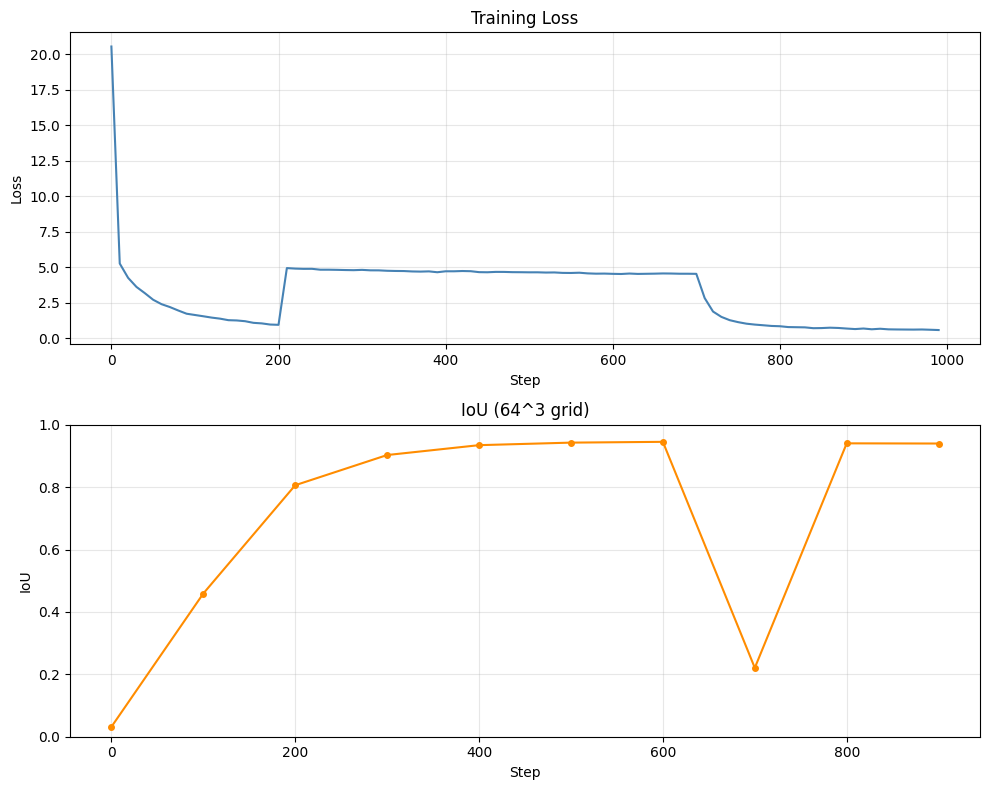

Saved training_curves.png


In [19]:
loss_hist, iou_hist, iou_steps = train(epochs=1000, data=mesh, no_surface=10000, no_off_surface=15000, model=model, loss=model_loss, optimizer=optimizer, scene=mesh.scene, pruning_module=prune_DepGraph)
np.savez(
    "lucy_weights/history/DepGraph_history.npz",
    loss=np.array(loss_hist),
    iou=np.array(iou_hist),
    steps=np.array(iou_steps)
)
torch.save(model.state_dict(), "lucy_weights/DepGraph.pth")

In [20]:
model.neuron_counts()

Neuron counts per layer:
----------------------------------------
Hidden layer  0:  256 neurons
Hidden layer  1:  102 neurons
Hidden layer  2:  102 neurons
Final layer    :    1 neurons


In [21]:
model = si.SIRENSDF(hidden_dims=[256, 102, 102])
missing, unexpected = model.load_state_dict(torch.load("lucy_weights/DepGraph.pth", map_location=torch.device("cuda")))
model.eval()
model.to(torch.device("cuda"))
print(missing)
print(unexpected)
marching_cubes.write_obj("lucy_128_DepGraph.obj", model=model, resolution=128, level=0.0)

[]
[]


/tmp/ipykernel_52318/1721773561.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  missing, unexpected = model.load_state_dict(torch.load("lucy_weights/DepGraph.pth", map_l

In [22]:
chamfer, hausdorff = chamfer_hausdorff("lucy_128_DepGraph.obj", "lucy_128_gt.obj")
print(f"chamfer: {chamfer:.4f} | hausdorff: {hausdorff:.4f}")

mesh1 triangles: 45146, vertices: 30392
mesh2 triangles: 44780, vertices: 30177
chamfer: 0.0043 | hausdorff: 0.0400


## AIRe: Model training with densification

In [23]:
set_seeds()
model = si.SIRENSDF(hidden_dims=[151, 256, 256])
prune_AIRe = pm.AIRe(model, 0.6)
model_loss = loss.Loss(lambda_surface=175,  lambda_eikonal=1, lambda_normal=15, lambda_inter=4, lambda_off=15, lambda_twd=1e-3, model=model, pruning_module=prune_AIRe)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4*2)

tensor([2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
        2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
        2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       device='cuda:0')
Added 46 frequencies to the embedding layer.
Step 0 | IoU 0.0355 | Loss 19.0581
Step 10 | Loss 4.85

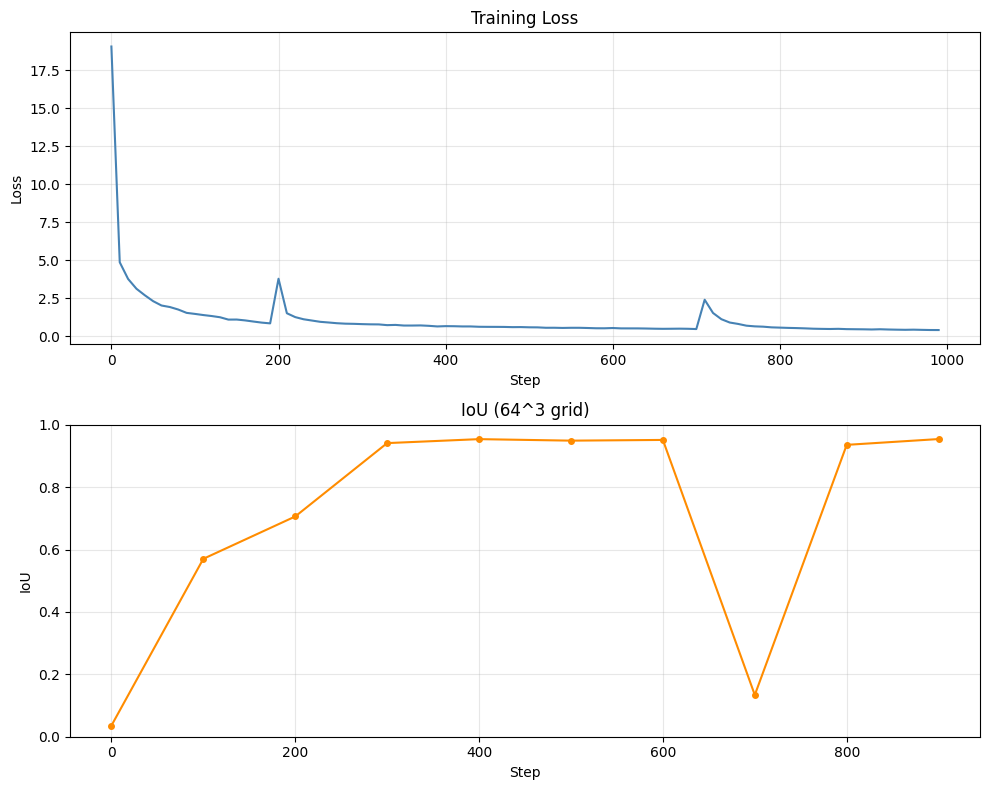

Saved training_curves.png


In [24]:
loss_hist, iou_hist, iou_steps = train(epochs=1000, data=mesh, no_surface=10000, no_off_surface=15000, model=model, loss=model_loss, optimizer=optimizer, scene=mesh.scene, pruning_module=prune_AIRe, densification=True)
np.savez(
    "lucy_weights/history/AIRe_densified_history.npz",
    loss=np.array(loss_hist),
    iou=np.array(iou_hist),
    steps=np.array(iou_steps)
)
torch.save(model.state_dict(), "lucy_weights/AIRe_densified.pth")

In [25]:
model.neuron_counts()

Neuron counts per layer:
----------------------------------------
Hidden layer  0:  256 neurons
Hidden layer  1:  103 neurons
Hidden layer  2:  103 neurons
Final layer    :    1 neurons


In [35]:
model = si.SIRENSDF(hidden_dims=[256, 103, 103])
missing, unexpected = model.load_state_dict(torch.load("lucy_weights/AIRe_densified.pth", map_location=torch.device("cuda")))
model.eval()
model.to(torch.device("cuda"))
print(missing)
print(unexpected)
marching_cubes.write_obj("lucy_256_AIRe_densified.obj", model=model, resolution=256, level=0.0)

/tmp/ipykernel_52318/3643900041.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  missing, unexpected = model.load_state_dict(torch.load("lucy_weights/AIRe_densified.pth",

[]
[]


In [27]:
chamfer, hausdorff = chamfer_hausdorff("lucy_128_AIRe_densified.obj", "lucy_128_gt.obj")
print(f"chamfer: {chamfer:.4f} | hausdorff: {hausdorff:.4f}")

mesh1 triangles: 46176, vertices: 31240
mesh2 triangles: 44780, vertices: 30177
chamfer: 0.0043 | hausdorff: 0.7822


## DepGraph: Model training with densification

In [28]:
set_seeds()
model = si.SIRENSDF(hidden_dims=[151, 256, 256]).to(torch.device("cuda"))
prune_DepGraph = pm.DepGraph(model, 0.6)
model_loss = loss.Loss(lambda_surface=175,  lambda_eikonal=1, lambda_normal=15, lambda_inter=4, lambda_off=15, lambda_twd=1e-3, model=model, pruning_module=prune_DepGraph)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4*2)

tensor([2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
        2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
        2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       device='cuda:0')
Added 46 frequencies to the embedding layer.
Step 0 | IoU 0.0355 | Loss 19.0581
Step 10 | Loss 4.85

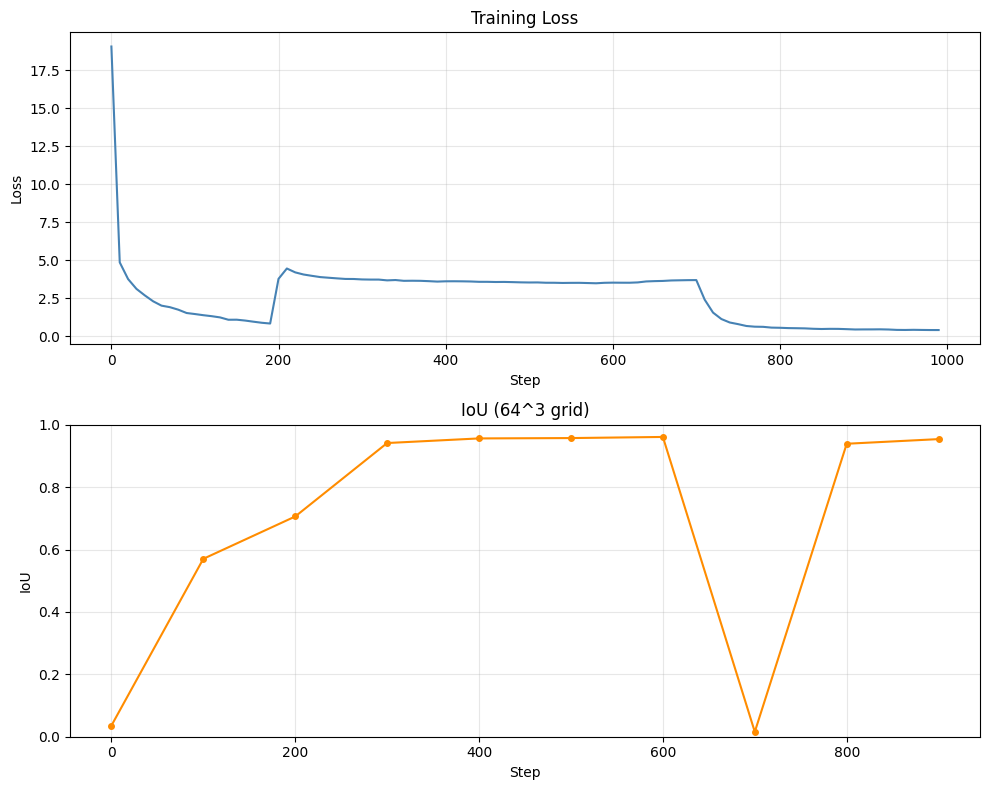

Saved training_curves.png


In [29]:
loss_hist, iou_hist, iou_steps = train(epochs=1000, data=mesh, no_surface=10000, no_off_surface=15000, model=model, loss=model_loss, optimizer=optimizer, scene=mesh.scene, pruning_module=prune_DepGraph, densification=True)
np.savez(
    "lucy_weights/history/DepGraph_densified_history.npz",
    loss=np.array(loss_hist),
    iou=np.array(iou_hist),
    steps=np.array(iou_steps)
)
torch.save(model.state_dict(), "lucy_weights/DepGraph_densified.pth")

In [30]:
model.neuron_counts()

Neuron counts per layer:
----------------------------------------
Hidden layer  0:  256 neurons
Hidden layer  1:  102 neurons
Hidden layer  2:  102 neurons
Final layer    :    1 neurons


In [34]:
model = si.SIRENSDF(hidden_dims=[256, 102, 102])
missing, unexpected = model.load_state_dict(torch.load("lucy_weights/DepGraph_densified.pth", map_location=torch.device("cuda")))
model.eval()
model.to(torch.device("cuda"))
print(missing)
print(unexpected)
marching_cubes.write_obj("lucy_256_DepGraph_densified.obj", model=model, resolution=256, level=0.0)

/tmp/ipykernel_52318/2002154015.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  missing, unexpected = model.load_state_dict(torch.load("lucy_weights/DepGraph_densified.p

[]
[]


In [32]:
chamfer, hausdorff = chamfer_hausdorff("lucy_128_DepGraph_densified.obj", "lucy_128_gt.obj")
print(f"chamfer: {chamfer:.4f} | hausdorff: {hausdorff:.4f}")

mesh1 triangles: 46060, vertices: 31051
mesh2 triangles: 44780, vertices: 30177
chamfer: 0.0047 | hausdorff: 0.9561


In [37]:
write_obj("lucy_256_gt.obj", mesh.scene, 256, 0.0)